In [127]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import keras

from matplotlib import pyplot as plt
from keras import layers, models, regularizers
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

In [128]:
BATCH_SIZE = 32
IMG_SIZE = (128, 128)

In [129]:
IMAGES_DIR = "../data/images"
MASKS_DIR = "../data/masks/"
CSV_PATH = "../data/GroundTruth.csv"

In [130]:
metadata = pd.read_csv(CSV_PATH)

print(metadata.head())
print(metadata.info())

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  str    
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), str(1)
memory usage: 626.1 KB
None


#### CLASSES

As sete classes utilizadas são:

- **MEL:** Melanoma
- **NV:** Nevos Melanocíticos
- **BCC:** Carcinoma Basocelular
- **AKIEC:** Queratose Actínica
- **BKL:** Queratose Benigna
- **DF:** Dermatofibroma
- **VASC:** Lesão Vascular

São criados dois dicionários:

- `class_code`: nome da classe para número
- `class_name`: número para nome da classe

In [131]:
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

class_code = {label: code for code, label in enumerate(classes)}
class_name = {code: label for code, label in enumerate(classes)}

print(class_code)
print(class_name)

{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}
{0: 'MEL', 1: 'NV', 2: 'BCC', 3: 'AKIEC', 4: 'BKL', 5: 'DF', 6: 'VASC'}


### CRIAÇÃO DOS RÓTULOS CODIFICADOS

A função abaixo lê os nomes das imagens disponíveis na pasta `data/images`, cruza esses nomes com o arquivo `GroundTruth.csv` e transforma a classe de cada imagem em um valor inteiro.

Esse formato é necessário porque a CNN será treinada com `SparseCategoricalCrossEntropy`.

In [132]:
def get_coded_labels(directory, metadata, class_code):
    image_names = [
        x.rsplit(".", 1)[0]
        for x in os.listdir(directory)
        if x.lower().endswith((".jpg", ",jpeg", ".png"))
    ]

    image_df = pd.DataFrame({"image": sorted(image_names)})

    merged = image_df.merge(metadata, on="image", how="inner")

    coded_labels = merged[classes].idxmax(axis=1).map(lambda x: class_code[x])

    return list(coded_labels)

### CRIAÇÃO DO DATASET

O dataset é criado redimensionando todas as imagens, associando cada imagem ao seu rótulo numérico e convertendo-as em um objeto `tf.data.Dataset`.

In [133]:
dataset = keras.utils.image_dataset_from_directory(
    directory=IMAGES_DIR,
    labels=get_coded_labels(IMAGES_DIR, metadata, class_code),
    batch_size=None,
    label_mode="int",
    shuffle=True,
    image_size=IMG_SIZE
)

Found 10015 files belonging to 7 classes.


In [134]:
train_ds, test_ds = keras.utils.split_dataset(
    dataset,
    left_size=0.8,
    shuffle=True,
    seed=42
)

### DATA AUGMENTATION

Foi utilizado Data Augmentation no conjunto de treino. As imagens foram rotacionas e espelhadas horizontalmente.

A distribuição numérica das classes permaneceu inalterada, pois as transformações foram aplicadas em tempo de execução, dinamicamente durante o treinamento, sem duplicar fisicamente as imagens no dataset.

In [135]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images, training=True)
    
    return images, labels

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

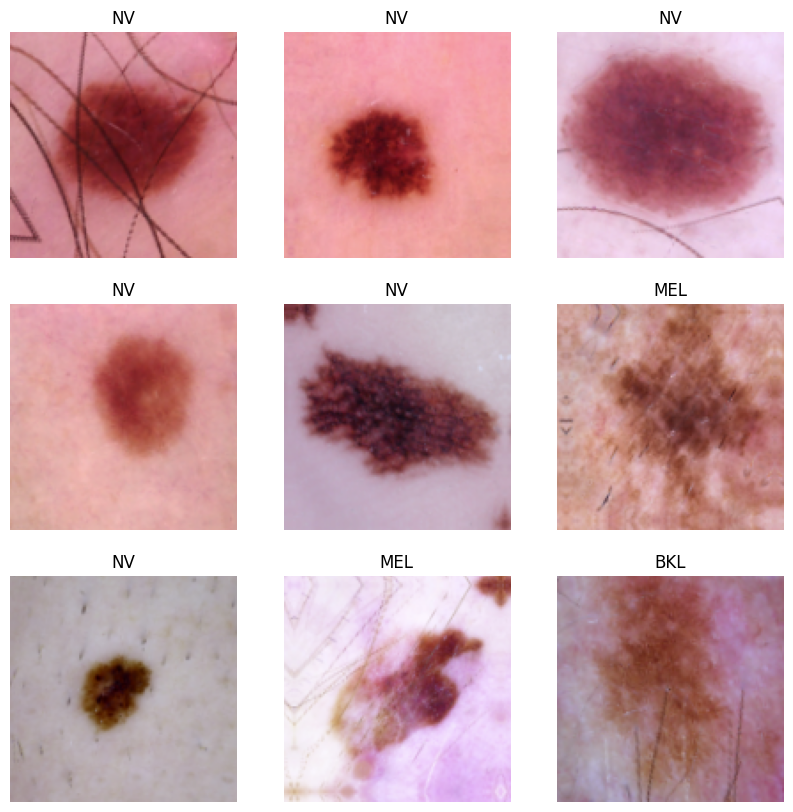

In [136]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        plt.title(class_name[int(labels[i].numpy())])
        plt.axis("off")

plt.show()

Quantidade de imagens no conjunto de treino: 8012


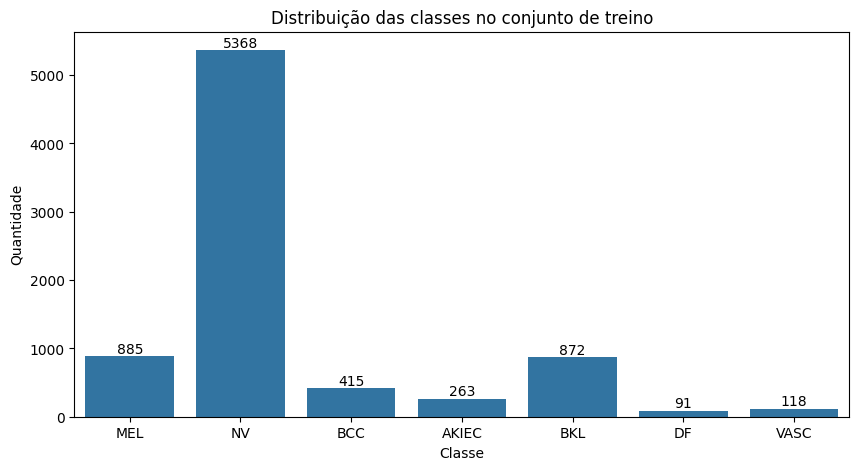

MEL       885.0
NV       5368.0
BCC       415.0
AKIEC     263.0
BKL       872.0
DF         91.0
VASC      118.0
dtype: object


In [137]:
train_label_df = pd.DataFrame(columns=classes)

for images, labels in train_ds.as_numpy_iterator():
    label_array = np.zeros((len(labels), len(classes)))

    for i, label in enumerate(labels):
        label_array[i, int(label)] = 1

    batch_df = pd.DataFrame(label_array, columns=classes)
    train_label_df = pd.concat([train_label_df, batch_df], ignore_index=True)

card = len(train_label_df)
print("Quantidade de imagens no conjunto de treino:", card)

label_counts = train_label_df.sum()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribuição das classes no conjunto de treino")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

print(label_counts)

In [138]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(len(classes))
])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,951 (980.28 KB)

 Trainable params: 250,247 (977.53 KB)

 Non-trainable params: 704 (2.75 KB)

In [139]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [140]:
y_train_labels = []

for images, labels in train_ds:
    y_train_labels.extend(labels.numpy())

y_train_labels = np.array(y_train_labels)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(classes)),
    y=y_train_labels
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_values)
}

print(class_weights)

{0: np.float64(1.2933010492332526), 1: np.float64(0.21322120502448372), 2: np.float64(2.7580034423407915), 3: np.float64(4.351982618142314), 4: np.float64(1.3125819134993446), 5: np.float64(12.577708006279435), 6: np.float64(9.699757869249394)}


In [141]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [142]:
history = model.fit(
    train_ds,
    epochs=200,
    validation_data=test_ds,
    callbacks=[early_stopping],
    class_weight=class_weights
)

Epoch 1/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 202ms/step - accuracy: 0.3427 - loss: 1.9048 - val_accuracy: 0.0135 - val_loss: 2.2977
Epoch 2/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 257ms/step - accuracy: 0.4099 - loss: 1.7180 - val_accuracy: 0.3440 - val_loss: 1.7583
Epoch 3/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 340ms/step - accuracy: 0.4265 - loss: 1.6477 - val_accuracy: 0.4319 - val_loss: 1.5861
Epoch 4/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 78s 308ms/step - accuracy: 0.4418 - loss: 1.5847 - val_accuracy: 0.4249 - val_loss: 1.6617
Epoch 5/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 76s 301ms/step - accuracy: 0.4526 - loss: 1.5348 - val_accuracy: 0.4259 - val_loss: 1.6477
Epoch 6/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 79s 314ms/step - accuracy: 0.4639 - loss: 1.5347 - val_accuracy: 0.4054 - val_loss: 1.7845
Epoch 7/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 80s 318ms/step - accuracy: 0.4713 - loss: 1.4838 - val_accuracy: 0.4428 - val_loss: 1.6041
Epoch 8/200
251/251 ━━━━━━━━━━━━━━━━━━━━ 81s 323ms/step - accuracy: 0.4841 -

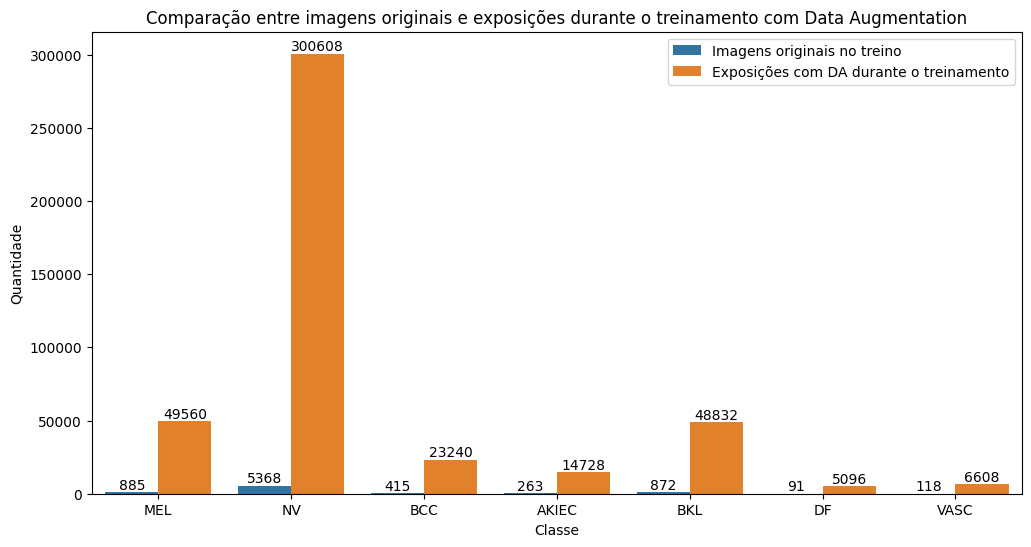

In [143]:
epochs = len(history.history["loss"])

comparison_df = pd.DataFrame({
    "Classe": label_counts.index,
    "Imagens originais no treino": label_counts.values,
    "Exposições com DA durante o treinamento": (label_counts * epochs).values
})

comparison_df_melted = comparison_df.melt(
    id_vars="Classe",
    var_name="Tipo",
    value_name="Quantidade"
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=comparison_df_melted,
    x="Classe",
    y="Quantidade",
    hue="Tipo"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Comparação entre imagens originais e exposições durante o treinamento com Data Augmentation")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.legend(title="")
plt.show()

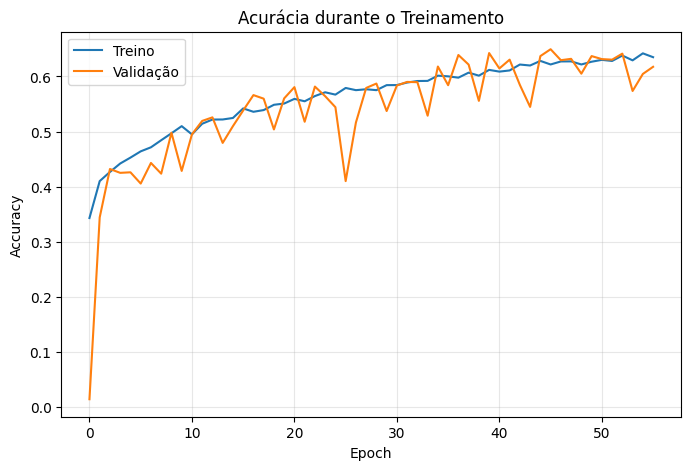

In [144]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Acurácia durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

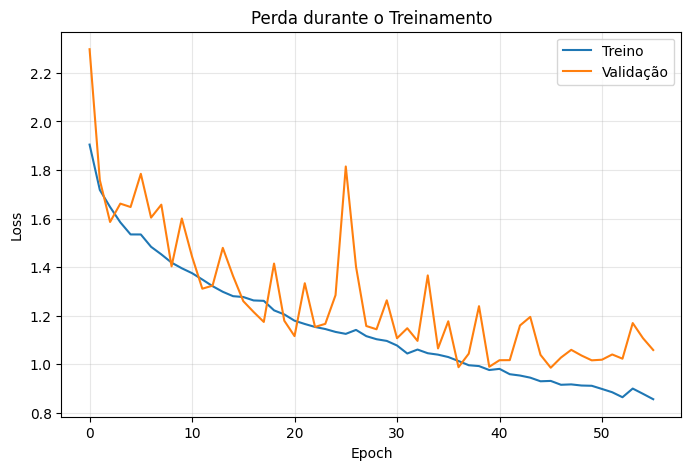

In [145]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perda durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [146]:
probability_model = tf.keras.Sequential([
    model,
    layers.Softmax()
])

In [147]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = probability_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

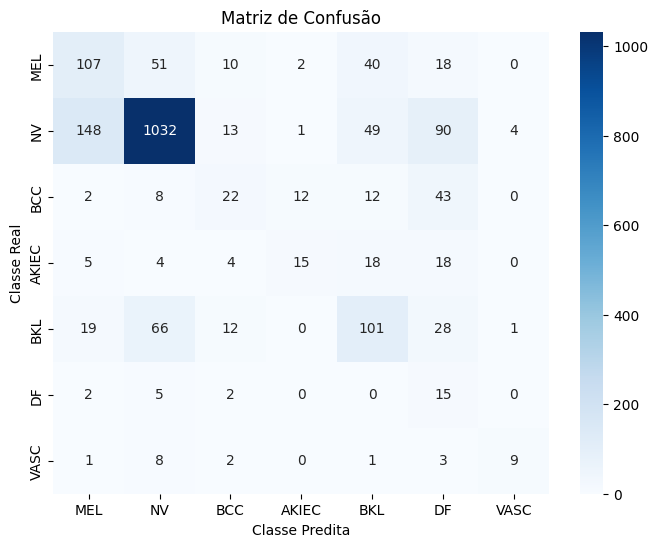

In [148]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

In [149]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print("Relatório de Classificação:\n")
print(report)

Relatório de Classificação:

              precision    recall  f1-score   support

         MEL     0.3768    0.4693    0.4180       228
          NV     0.8790    0.7719    0.8220      1337
         BCC     0.3385    0.2222    0.2683        99
       AKIEC     0.5000    0.2344    0.3191        64
         BKL     0.4570    0.4449    0.4509       227
          DF     0.0698    0.6250    0.1255        24
        VASC     0.6429    0.3750    0.4737        24

    accuracy                         0.6495      2003
   macro avg     0.4663    0.4490    0.4111      2003
weighted avg     0.7227    0.6495    0.6780      2003



In [150]:
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("MÉTRICAS GERAIS DO MODELO")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"\nMacro Average:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall: {recall_macro:.4f}")
print(f"  F1-Score: {f1_macro:.4f}")
print(f"\nWeighted Average:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall: {recall_weighted:.4f}")
print(f"  F1-Score: {f1_weighted:.4f}")

MÉTRICAS GERAIS DO MODELO

Accuracy: 0.6495

Macro Average:
  Precision: 0.4663
  Recall: 0.4490
  F1-Score: 0.4111

Weighted Average:
  Precision: 0.7227
  Recall: 0.6495
  F1-Score: 0.6780


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


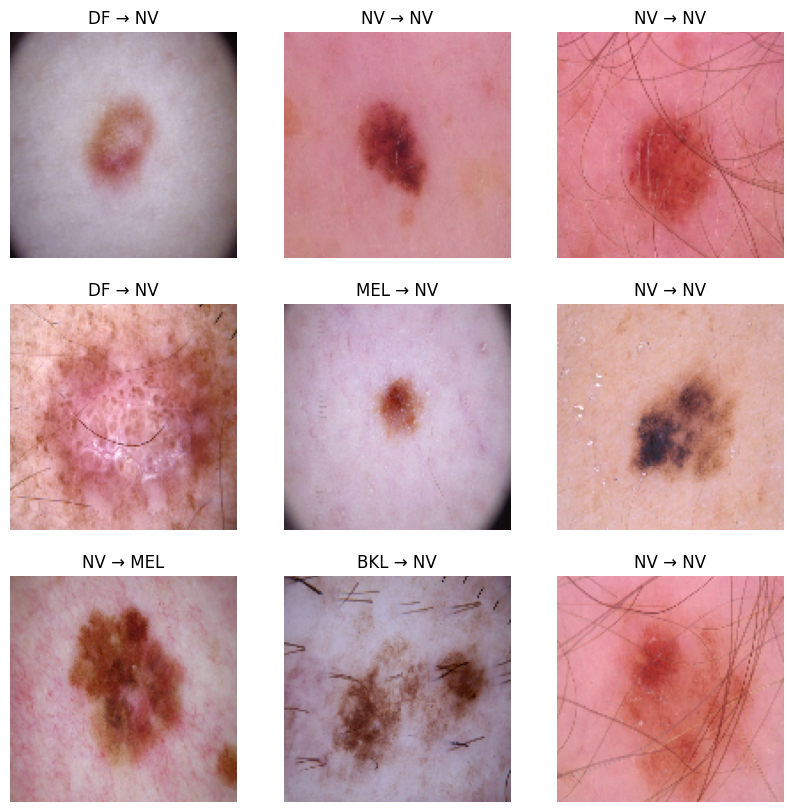

In [151]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    predictions = probability_model.predict(images)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        true_label = class_name[int(labels[i].numpy())]
        pred_label = class_name[int(np.argmax(predictions[i]))]

        plt.title(f"{true_label} → {pred_label}")
        plt.axis("off")

plt.show()

In [152]:
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print("\nDiagnóstico final:")
print(f"Train accuracy: {final_train_acc:.4f}")
print(f"Val accuracy: {final_val_acc:.4f}")
print(f"Train loss: {final_train_loss:.4f}")
print(f"Val loss: {final_val_loss:.4f}")


Diagnóstico final:
Train accuracy: 0.6350
Val accuracy: 0.6176
Train loss: 0.8560
Val loss: 1.0587
